<a href="https://colab.research.google.com/github/sksujinair-lgtm/assignment-02-bitsom_ba_2511661/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler took a wicket with a yorker",
    "The team won the cricket match by 5 runs",
    "Fielders saved crucial runs near the boundary",

    # Cooking (3)
    "I added spices to enhance the flavor of the curry",
    "The chef baked a delicious chocolate cake",
    "Boiling vegetables helps retain nutrients",

    # Cybersecurity (3)
    "Strong passwords are essential for cybersecurity",
    "Phishing attacks can steal sensitive information",
    "Firewalls protect systems from unauthorized access"
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

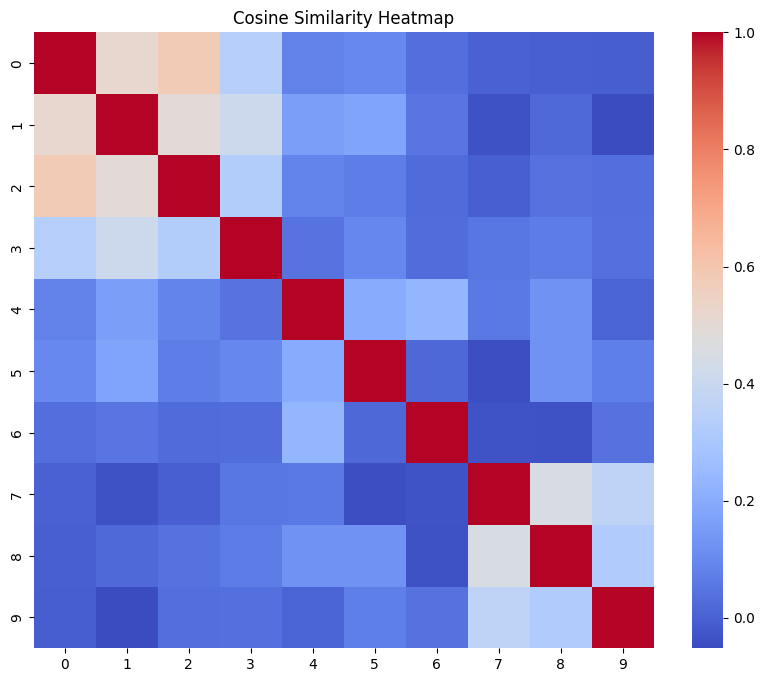

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_2_idx = similarities.argsort()[-2:][::-1]

for idx in top_2_idx:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Sentence: The bowler took a wicket with a yorker
Similarity Score: 0.7487

Sentence: The team won the cricket match by 5 runs
Similarity Score: 0.5705

